In [ ]:
!nvidia-smi

Thu Dec 11 05:05:55 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 79.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=8a1b0a3630246d8d293f686d73b6987bb35ed2ae0e85454fad1072aec1eecaa0
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
!pip install grad-cam

In [ ]:
# CELL 1 — Imports, device, and mount Drive
import os, glob, math
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt

from torchvision import transforms
# Hugging Face ViT components (we'll load the model in a later cell)
from transformers import ViTModel, AutoFeatureExtractor

# Grad-CAM utilities (from the grad-cam / pytorch-grad-cam package)
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# mount Google Drive (Colab)
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# --- Reusable transforms ---
# ResNet-style transform (matches training from Step 5)
IMG_SIZE = 512
resnet_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# ViT transform placeholder (we will set exact mean/std after loading the feature extractor)
vit_transform = None

print("Transforms ready. ResNet image size =", IMG_SIZE)


Using device: cuda
Mounted at /content/drive
Transforms ready. ResNet image size = 512


In [ ]:
import os, glob

# Adjust this to your Test Images folder (or use Train Images if you want)
BASE = "/content/drive/MyDrive/DrishtiGS/Test/Images"

# many users have uppercase folder names — try both variants
possible_normal = [
    os.path.join(BASE, "normal"),
    os.path.join(BASE, "NORMAL"),
    os.path.join(BASE, "Normal")
]
possible_glaucoma = [
    os.path.join(BASE, "glaucoma"),
    os.path.join(BASE, "GLAUCOMA"),
    os.path.join(BASE, "Glaucoma")
]

def find_existing(path_list):
    for p in path_list:
        if os.path.isdir(p):
            return p
    return None

normal_dir = find_existing(possible_normal)
glaucoma_dir = find_existing(possible_glaucoma)

print("Detected Normal dir   :", normal_dir)
print("Detected Glaucoma dir :", glaucoma_dir)

# helper: pick one example path from a folder (first match of common extensions)
def sample_image_path(folder):
    if folder is None:
        return None
    exts = ("*.jpg","*.png","*.jpeg","*.JPG","*.PNG","*.JPEG")
    files = []
    for ext in exts:
        files += glob.glob(os.path.join(folder, ext))
    return files[0] if files else None

sample_normal = sample_image_path(normal_dir)
sample_glaucoma = sample_image_path(glaucoma_dir)

print("Example normal image   :", sample_normal)
print("Example glaucoma image :", sample_glaucoma)


Detected Normal dir   : /content/drive/MyDrive/DrishtiGS/Test/Images/normal
Detected Glaucoma dir : /content/drive/MyDrive/DrishtiGS/Test/Images/glaucoma
Example normal image   : /content/drive/MyDrive/DrishtiGS/Test/Images/normal/drishtiGS_085.png
Example glaucoma image : /content/drive/MyDrive/DrishtiGS/Test/Images/glaucoma/drishtiGS_005.png


In [ ]:
# CELL 3 — Load ResNet model for Grad-CAM

import torchvision.models as models
import torch.nn as nn

# Load pretrained ResNet50 (ImageNet)
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Replace the last FC layer with a single-output classifier
# (since our task is binary classification; Grad-CAM requires a valid output)
resnet.fc = nn.Linear(resnet.fc.in_features, 1)

# Move to device and set eval mode
resnet = resnet.to(device)
resnet.eval()

# If you have your trained weights from your earlier step, load them here:
# Example:
# resnet.load_state_dict(torch.load("/content/drive/MyDrive/DrishtiGS/resnet50_drishti_baseline.pth"))

print("ResNet model loaded and ready for Grad-CAM.")

# ---- Grad-CAM target layer ----
# For ResNet50, the recommended last convolution layer is layer4[-1]
target_layer = resnet.layer4[-1]
print("Grad-CAM target layer:", target_layer)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 130MB/s]


ResNet model loaded and ready for Grad-CAM.
Grad-CAM target layer: Bottleneck(
  (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
)


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch

def gradcam_for_image(model, target_layer, image_path, resize_for_display=True, img_size=IMG_SIZE, transform=resnet_transform):
    """
    Returns:
      cam_image : RGB uint8 array with heatmap overlay (for plt.imshow)
      heatmap   : float HxW array (0..1)
      rgb       : original image float HxW3 array (0..1)
    Notes:
      - This function uses a resized copy of the image for both model input and display,
        so Grad-CAM heatmap and rgb overlay will have the same shape and won't broadcast error.
    """
    # load original and create a resized copy for both model input and display
    img_orig = Image.open(image_path).convert("RGB")
    # use a resized image for both model input and rgb overlay (avoid mismatched shapes)
    img_resized = img_orig.resize((img_size, img_size), resample=Image.BILINEAR)

    rgb = np.array(img_resized).astype(np.float32) / 255.0  # HxWx3 float in 0..1

    # prepare input using the same transform (which also resizes, but we already resized above)
    # ensure we pass a PIL image of the correct size to the transform
    input_tensor = transform(img_resized).unsqueeze(0).to(device)  # [1,3,H,W]

    # Create GradCAM object and call it — handle library API differences gracefully
    try:
        cam = GradCAM(model=model, target_layers=[target_layer], use_cuda=(device.type=="cuda"))
    except TypeError:
        cam = GradCAM(model=model, target_layers=[target_layer])

    try:
        grayscale_cam = cam(input_tensor=input_tensor)  # shape (B, H, W)
        heatmap = grayscale_cam[0]  # H x W float 0..1
        cam_image = show_cam_on_image(rgb, heatmap, use_rgb=True)  # uint8 overlay
    finally:
        # clean up hooks and the object to avoid destructor warnings
        try:
            cam.clear_hooks()
        except Exception:
            pass
        del cam

    return cam_image, heatmap, rgb


In [ ]:
!pip install --upgrade git+https://github.com/jacobgil/pytorch-grad-cam.git

  Cloning https://github.com/jacobgil/pytorch-grad-cam.git to /tmp/pip-req-build-z3y4nwkv
  Running command git clone --filter=blob:none --quiet https://github.com/jacobgil/pytorch-grad-cam.git /tmp/pip-req-build-z3y4nwkv
  Resolved https://github.com/jacobgil/pytorch-grad-cam.git to commit 781dbc0d16ffa95b6d18b96b7b829840a82d93d1
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# CELL 5 — Load ViT model + feature extractor + ViT preprocess
from transformers import AutoFeatureExtractor, ViTModel

vit_model_name = "google/vit-base-patch16-224-in21k"
feature_extractor = AutoFeatureExtractor.from_pretrained(vit_model_name)
vit = ViTModel.from_pretrained(vit_model_name, output_attentions=True).to(device)
vit.eval()

VIT_IMG_SIZE = feature_extractor.size["shortest_edge"] if "shortest_edge" in feature_extractor.size else 224
vit_transform = transforms.Compose([
    transforms.Resize((VIT_IMG_SIZE, VIT_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=feature_extractor.image_mean, std=feature_extractor.image_std)
])
print("ViT image size:", VIT_IMG_SIZE)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/vit/feature_extraction_vit.py:30: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

ViT image size: 224


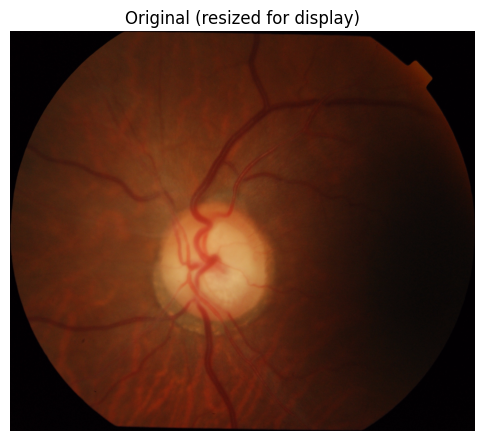

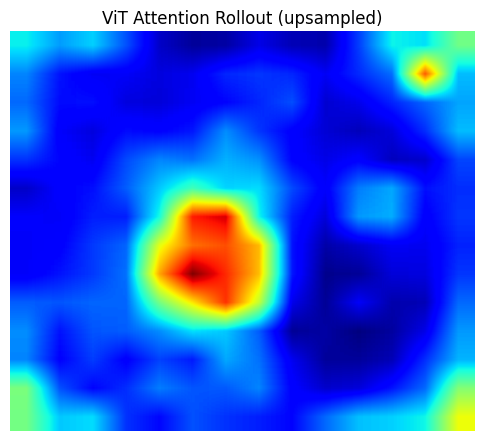

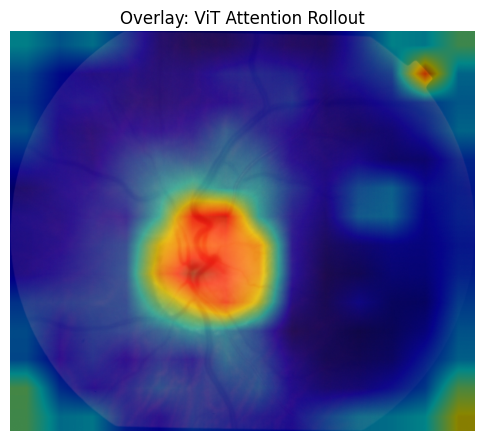

In [ ]:

import numpy as np
import math
from PIL import Image
import torch

def attention_rollout_from_vit(model, image_path, vit_transform, discard_ratio=0.0):
    """
    model: HuggingFace ViTModel with output_attentions=True
    image_path: path to image (PIL readable)
    vit_transform: transform used for ViT (resize+normalize)
    discard_ratio: fraction of smallest attention values to zero at each layer (0.0..0.5)
    returns:
       heatmap_arr: HxW float array in 0..1 (upsampled to original image size)
       rgb_orig   : original image HxW3 float array in 0..1 (for plotting)
    """
    # load original image (keep original size for final upsample)
    img_orig = Image.open(image_path).convert("RGB")
    rgb_orig = np.array(img_orig).astype(np.float32) / 255.0

    # prepare ViT input (resized)
    vit_input = vit_transform(img_orig).unsqueeze(0).to(device)  # [1,3,H_vit,W_vit]

    # forward pass to get attentions
    with torch.no_grad():
        outputs = model(vit_input)  # returns BaseModelOutputWithPoolingAndNoAttention unless output_attentions=True
        attentions = outputs.attentions  # tuple(len = n_layers) of (batch, n_heads, seq_len, seq_len)

    # validate attentions
    if attentions is None:
        raise RuntimeError("Model did not return attentions. Make sure output_attentions=True when loading ViTModel.")

    # Convert to numpy (avg heads). attentions[l] -> (batch, n_heads, seq_len, seq_len)
    attn_mat = []
    for att in attentions:
        # att: torch.Tensor (1, n_heads, seq_len, seq_len)
        a = att.cpu().squeeze(0).mean(axis=0)   # (seq_len, seq_len)  # average over heads
        attn_mat.append(a.numpy())

    num_tokens = attn_mat[0].shape[0]  # includes CLS token
    rollout = np.eye(num_tokens)

    # Multiply through layers
    for a in attn_mat:
        # optional: zero out very small attention values
        if discard_ratio and discard_ratio > 0.0:
            flat = a.flatten()
            thresh = np.percentile(flat, discard_ratio * 100.0)
            a = np.where(a < thresh, 0, a)

        a = a + np.eye(num_tokens)               # add identity (residual connection)
        a = a / a.sum(axis=-1, keepdims=True)    # row-normalize
        rollout = a @ rollout

    # CLS token attention to patches (ignore CLS->CLS)
    cls_attn = rollout[0, 1:]  # length = num_patches

    # reshape to square grid of patches
    num_patches = cls_attn.shape[0]
    side = int(math.sqrt(num_patches))
    if side * side != num_patches:
        # fallback: attempt to infer using model config (if available)
        try:
            patch_size = model.config.patch_size
            img_size = model.config.image_size if hasattr(model.config, "image_size") else vit_input.shape[-1]
            side = img_size // patch_size
        except Exception:
            side = int(math.sqrt(num_patches))  # best effort

    heatmap = cls_attn.reshape(side, side)

    # normalize heatmap 0..1
    heatmap = heatmap - heatmap.min()
    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()

    # upsample to original image size
    heatmap_img = Image.fromarray((heatmap * 255).astype(np.uint8)).resize((rgb_orig.shape[1], rgb_orig.shape[0]), resample=Image.BILINEAR)
    heatmap_arr = np.array(heatmap_img).astype(np.float32) / 255.0

    return heatmap_arr, rgb_orig

# Quick test and display (if sample available)
import matplotlib.pyplot as plt
from pytorch_grad_cam.utils.image import show_cam_on_image  # re-use overlay util

if sample_glaucoma:
    rollout_map, rgb = attention_rollout_from_vit(vit, sample_glaucoma, vit_transform, discard_ratio=0.0)
    plt.figure(figsize=(6,6)); plt.title("Original (resized for display)"); plt.imshow(rgb); plt.axis("off")
    plt.figure(figsize=(6,6)); plt.title("ViT Attention Rollout (upsampled)"); plt.imshow(rollout_map, cmap="jet"); plt.axis("off")
    # also overlay rollout on image
    overlay = show_cam_on_image(rgb, rollout_map, use_rgb=True)
    plt.figure(figsize=(6,6)); plt.title("Overlay: ViT Attention Rollout"); plt.imshow(overlay); plt.axis("off")
else:
    print("No glaucoma sample found; use sample_normal or adjust paths.")


In [ ]:
vit = ViTModel.from_pretrained(vit_model_name, output_attentions=True).to(device)